## 1. Setup

Just making the first imports. 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.float_format", "{:.2f}".format)


## 2. Data loading

The original dataset contains more than 6 million transactions; which can be a lot. For the EDA phase, keeping the full dataset is useful because temporal effects and rare fraud patterns can disappear when sampling too aggressively, and i don't want to miss them for the rest of the project. But smart sampling will be very important after. 


In [2]:
df_origin = pd.read_csv("../data/raw/paysim.csv")
df = df_origin.copy()

df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


## 3. Dataset overview and data quality checks

Before analysing fraud patterns, the first step is to verify basic data quality:

- missing values;
- duplicate rows;
- data types;
- numerical ranges;
- categorical modalities.


In [4]:
# Missing values by column
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [5]:
# Duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicate_count}")


Number of duplicated rows: 0


In [6]:
# General numerical behaviour
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00
mean,243.40,179861.90,833883.10,855113.67,1100701.67,1224996.40,0.00,0.00
std,142.33,603858.23,2888242.67,2924048.50,3399180.11,3674128.94,0.04,0.00
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,156.00,13389.57,0.00,0.00,0.00,0.00,0.00,0.00
50%,239.00,74871.94,14208.00,0.00,132705.66,214661.44,0.00,0.00
75%,335.00,208721.48,107315.18,144258.41,943036.71,1111909.25,0.00,0.00
max,743.00,92445516.64,59585040.37,49585040.37,356015889.35,356179278.92,1.00,1.00


In [7]:
# Low-cardinality categorical variables proportions
for col in df.select_dtypes(include="object"):
    if df[col].nunique() < 20:
        print(f"\n{col}")
        print(df[col].value_counts(normalize=True))



type
type
CASH_OUT   0.35
PAYMENT    0.34
CASH_IN    0.22
TRANSFER   0.08
DEBIT      0.01
Name: proportion, dtype: float64


### Insight — Dataset structure

The dataset contains numerical transaction attributes, categorical transaction types and account identifiers.

The variables `nameOrig` and `nameDest` should not be treated as ordinary categorical variables. They are account identifiers and may later be used to create behavioural features if necessary, but they are not suitable for naive one-hot encoding in a first baseline model.


## 4. Target variable analysis

The target variable is `isFraud`:

- `0`: legitimate transaction;
- `1`: fraudulent transaction.

The first question is whether the target is balanced.


In [8]:
target_distribution = df["isFraud"].value_counts().rename("count").to_frame()
target_distribution["percentage"] = df["isFraud"].value_counts(normalize=True) * 100
target_distribution


,count,percentage
isFraud,,
0,6354407,99.87
1,8213,0.13


### Insight — Severe class imbalance

Fraudulent transactions represent a very small fraction of the dataset (less than 0.15%). This has direct modelling consequences:

- accuracy is not a sufficient metric;
- recall, precision, F1-score will be more relevant;
- false negatives and false positives should eventually be interpreted through a business cost framework.

This confirms that the project should be treated as an imbalanced classification problem.


## 5. Fraud by transaction type

We now check whether fraud is uniformly distributed across transaction types.


In [9]:
fraud_by_type = (
    df.groupby("type")
      .agg(
          total_transactions=("isFraud", "count"),
          fraud_count=("isFraud", "sum"),
          fraud_rate=("isFraud", "mean"),
          avg_amount=("amount", "mean")
      )
      .sort_values("fraud_rate", ascending=False)
)

fraud_by_type


,total_transactions,fraud_count,fraud_rate,avg_amount
type,,,,
TRANSFER,532909,4097,0.01,910647.01
CASH_OUT,2237500,4116,0.00,176273.96
CASH_IN,1399284,0,0.00,168920.24
DEBIT,41432,0,0.00,5483.67
PAYMENT,2151495,0,0.00,13057.60


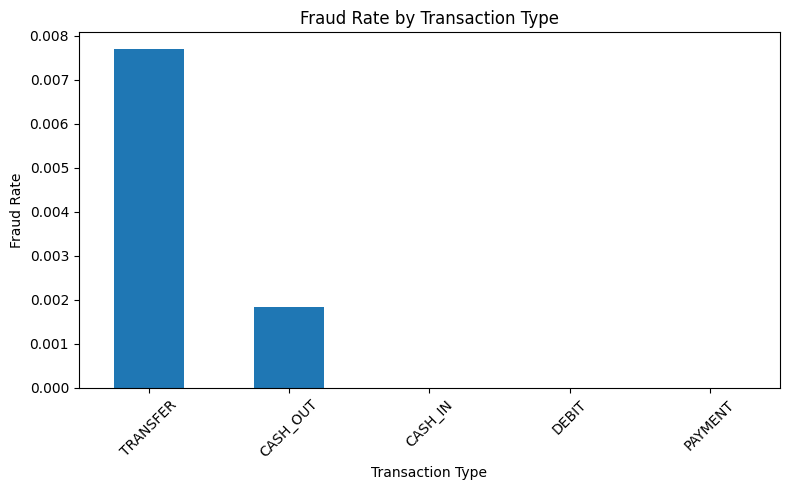

In [10]:
plt.figure(figsize=(8, 5))

fraud_by_type["fraud_rate"].sort_values(ascending=False).plot(kind="bar")

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Insight — Transaction type is a key fraud signal

Fraud is not evenly distributed across transaction types. Fraudulent activity is mainly concentrated in specific transaction categories, especially those involving money movement out of an account.

This motivates keeping `type` as a key feature in the first model. It also suggests that some engineered features may need to be interpreted differently depending on transaction type.


## 6. Temporal analysis

In PaySim, `step` represents simulated time. One step corresponds to one hour, and the dataset covers approximately 744 steps, or 31 days.

Instead of treating `step` only as a raw numerical variable, we derive the hour of the day. The objective is probably to spot a pattern at nighttime, where fraud might be more likely to happen. 


In [11]:
min_step = df["step"].min()
max_step = df["step"].max()

print(f"Minimum step: {min_step}")
print(f"Maximum step: {max_step}")
print(f"Approximate number of days: {max_step / 24:.2f}")


Minimum step: 1
Maximum step: 743
Approximate number of days: 30.96


In [12]:
df["hour_of_day"] = df["step"] % 24

df[["step", "hour_of_day"]].head()


,step,hour_of_day
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1


In [13]:
fraud_by_hour = (
    df.groupby("hour_of_day")
      .agg(
          total_transactions=("isFraud", "count"),
          fraud_count=("isFraud", "sum"),
          fraud_rate=("isFraud", "mean")
      )
      .reset_index()
)

fraud_by_hour


,hour_of_day,total_transactions,fraud_count,fraud_rate
0,0,71587,300,0.00
1,1,27111,358,0.01
2,2,9018,372,0.04
3,3,2007,326,0.16
4,4,1241,274,0.22
5,5,1641,366,0.22
6,6,3420,358,0.10
7,7,8988,328,0.04
8,8,26915,368,0.01
9,9,283518,341,0.00


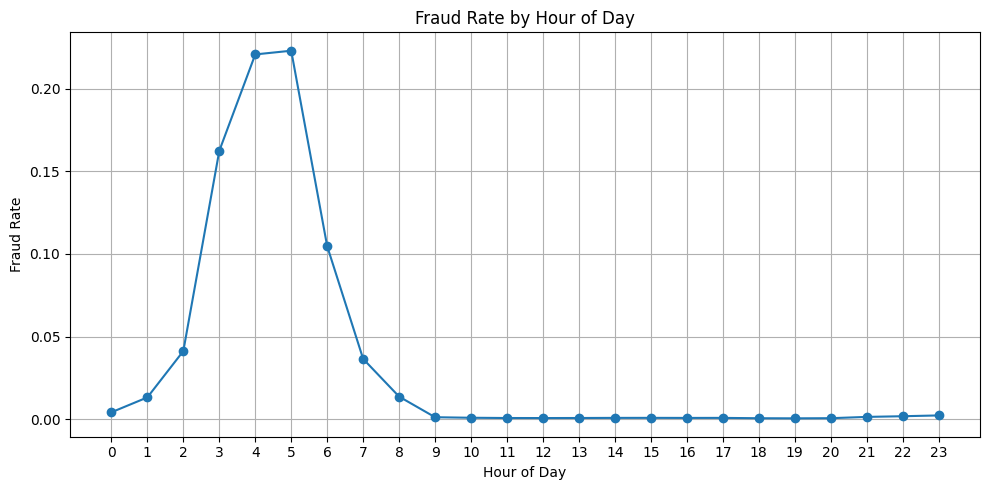

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    fraud_by_hour["hour_of_day"],
    fraud_by_hour["fraud_rate"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Hour of Day")
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()


In [15]:
# Candidate binary feature for later modelling
df["night_transaction"] = df["hour_of_day"].between(2, 7).astype(int)

pd.crosstab(
    df["night_transaction"],
    df["isFraud"],
    normalize="index"
)


isFraud,0,1
night_transaction,,
0,1.00,0.00
1,0.92,0.08


### Insight — Fraud is temporally structured

Validating my hypothesis, fraud does not appear uniformly distributed throughout the day. The fraud rate increases during specific night-time hours.


This is quite an interesting finding, but it might not change much things for the next phase of the project because of how much data is available. It is nice to notice that, and in any cases where fewer data were available i would probably had to pay more attention to sampling methods to train my potential models. It can also be a feature to be used in case i need to further optimize the future models. 

## 7. Amount analysis

Another intuitive hypothesis is to think that the variable `amount` might carry predictive power, since frauds might imply huge amount of money. We now analyse whether fraud risk changes across amount ranges.

Because transaction amounts are highly skewed, quantile-based bins are preferable to manually defined equal-width bins.


In [16]:
df["amount_quantile"] = pd.qcut(
    df["amount"],
    q=10,
    duplicates="drop"
)

fraud_rate_by_amount = (
    df.groupby("amount_quantile", observed=False)
      .agg(
          total_transactions=("isFraud", "count"),
          fraud_count=("isFraud", "sum"),
          fraud_rate=("isFraud", "mean"),
          avg_amount=("amount", "mean")
      )
)

fraud_rate_by_amount


,total_transactions,fraud_count,fraud_rate,avg_amount
amount_quantile,,,,
"(-0.001, 4501.3]",636263,148,0.00,2232.96
"(4501.3, 9866.158]",636261,128,0.00,7058.04
"(9866.158, 18092.028]",636262,148,0.00,13581.70
"(18092.028, 36371.35]",636262,365,0.00,25825.08
"(36371.35, 74871.94]",636262,617,0.00,54207.23
"(74871.94, 122563.784]",636262,592,0.00,98282.09
"(122563.784, 176801.919]",636262,581,0.00,148898.63
"(176801.919, 246611.22]",636262,503,0.00,209715.98
"(246611.22, 365423.309]",636262,719,0.00,298495.12


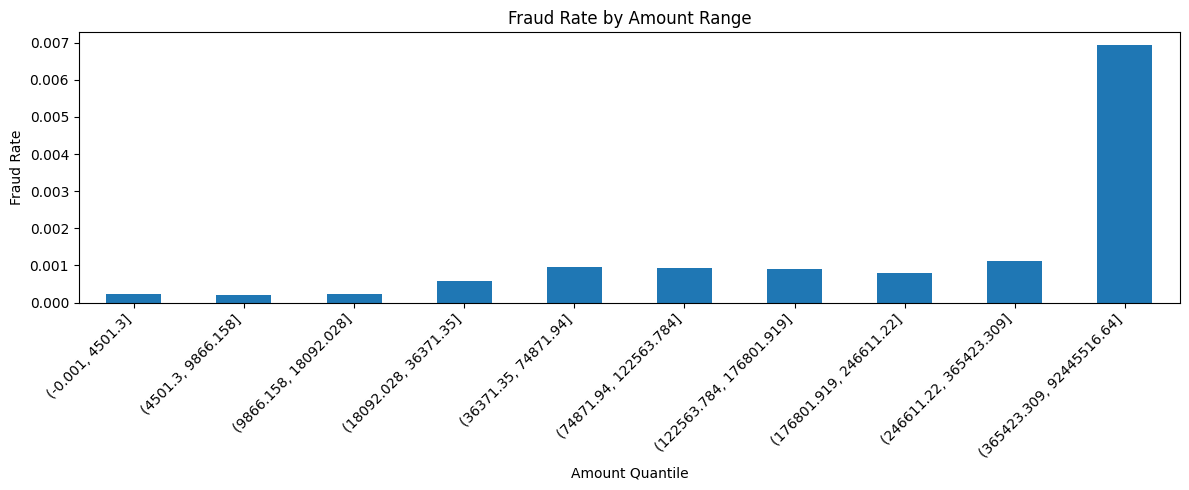

In [17]:
plt.figure(figsize=(12, 5))

fraud_rate_by_amount["fraud_rate"].plot(kind="bar")

plt.title("Fraud Rate by Amount Range")
plt.xlabel("Amount Quantile")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Insight — Amount-based risk signal

Studying this `amount` variable fraudulent transaction most likely imply huge amount of money, which gives it a good predictive power. 


## 8. Accounting consistency investigation

### Hypothesis

Fraudulent transactions may create abnormal accounting inconsistencies between old and new account balances.

For the origin account, a normal outgoing transaction should approximately satisfy:

`oldbalanceOrg - amount = newbalanceOrig`

For the destination account, a normal incoming transaction should approximately satisfy:

`oldbalanceDest + amount = newbalanceDest`

We test this hypothesis by creating balance error features.


In [18]:
# Initial idea investigated during EDA:
# origin_balance_error = oldbalanceOrg + amount - newbalanceOrig
# This formula is not correct for outgoing transactions from the origin account.
# The corrected formula is used below.

df["origin_balance_error"] = (
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
).abs()

# Destination account receives the amount.
df["dest_balance_error"] = (
    df["oldbalanceDest"]
    + df["amount"]
    - df["newbalanceDest"]
).abs()

df[["origin_balance_error", "dest_balance_error"]].describe()


,origin_balance_error,dest_balance_error
count,6362620.00,6362620.00
mean,201092.47,93599.07
std,606650.46,435056.98
min,0.00,0.00
25%,2954.23,0.00
50%,68677.26,5123.62
75%,249641.09,43421.33
max,92445516.64,75885725.63


In [19]:
df.groupby("isFraud")[["origin_balance_error", "dest_balance_error"]].mean()


,origin_balance_error,dest_balance_error
isFraud,,
0,201338.56,92756.96
1,10692.33,745138.59


In [20]:
df.groupby("isFraud")[["origin_balance_error", "dest_balance_error"]].describe()


origin_balance_error                                            \
                       count      mean       std  min     25%      50%   
isFraud                                                                  
0                 6354407.00 201338.56 606928.89 0.00 3034.31 69049.31   
1                    8213.00  10692.33 265146.13 0.00    0.00     0.00   

                              dest_balance_error                            \
              75%         max              count      mean        std  min   
isFraud                                                                      
0       249953.43 92445516.64         6354407.00  92756.96  429517.96 0.00   
1            0.00 10000000.00            8213.00 745138.59 1862744.92 0.00   

                                            
         25%     50%       75%         max  
isFraud                                     
0       0.00 5123.10  43227.16 75885725.63  
1       0.00 9511.69 452294.74 10000000.00

In [21]:
df["has_origin_error"] = (df["origin_balance_error"] > 0).astype(int)

pd.crosstab(
    df["has_origin_error"],
    df["isFraud"],
    normalize="index"
)


isFraud,0,1
has_origin_error,,
0,0.99,0.01
1,1.00,0.00


### Insight — Accounting errors are not prioritised for the first model

The accounting consistency hypothesis was useful, but the results makes those features doubtable. 

It is hard to say what a high origin balance error might predict. We can notice how fraudulent transactions are actually cleaner accounting transactions (with less errors), very most likely because most fraudulent transactions tend to just wipe the account entirely. I also think it is because of how the dataset has been simulated, and i could confirm that by deepening the analysis on merchant accounts and clients account, but it is a matter of curiosity at this point, not necessity. 

This feature could be investigated more, but it's potential for a first model is insufficient. 


## 9. EDA conclusion

This exploratory analysis identified several important insights:

1. **Class imbalance**: fraud is rare, so accuracy is not an appropriate primary metric.
2. **Transaction type**: fraud is concentrated in specific transaction types (CASH OUT and TRANSFER)
3. **Transaction amount**: fraud risk is specifically seen in very high transaction amounts (obviously this works on this specific data, i also think fraud can happen under lower transaction amounts, it is a known fraudulent technique used. But since those data doesn't back this assumption, i don't need to train a first model around it).
4. **Temporal behaviour**: fraud rate changes depending on the hour of day, and are very likely to happen at night between 2 to 7 am, with a peak between 4 and 5 am.
5. **Balance-related variables**: amount-to-balance relationships appear promising, since most fraudulent transactions might revolve around transfering or cashing-out most amount of money from an account.
6. **Accounting inconsistencies**: possible enrichment but not as useful for the first modelling iteration.

The next stage of the project should be to build a baseline model, starting with a simple Logistic Regression pipeline and then comparing it to tree-based models such as Random Forest or XGBoost.

As for evaluation, it should be conducted with metrics adapted to imbalanced classification, without relying on accuracy.



In [23]:
features = [
    "type",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "newbalanceOrig",
    "newbalanceDest",
]

target = "isFraud"

modeling_df = df[features + [target]].copy()
modeling_df.to_csv("../data/processed/modeling_df.csv")